# Bayesian Estimation of Temperature-Related and Day-to-Day Effects in PV Performance

Authors: Maria Krzyżowska, Julia Wiater

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("onemin-Ground-2016/2016/ground_model_data_9_16_5min.csv")

STAN_PRIOR1_PATH = Path("model_1_temperature_studentt_prior_predictive.stan")
STAN_MODEL1_PATH = Path("model_1_temperature_studentt.stan")
  
STAN_PRIOR2_PATH = Path("model_2_temperature_daily_offset_prior_predictive.stan")
STAN_MODEL2_PATH = Path("model_2_temperature_daily_offset.stan")



/Users/jwiater/Documents/private/da_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Problem formulation

### Problem statement

Photovoltaic power output is mainly driven by solar irradiance, but the same irradiance level can still lead to different power output depending on module temperature, weather conditions, measurement noise and day-specific operating conditions. Higher module temperature is expected to reduce PV performance mainly because the open-circuit voltage of a solar cell decreases as temperature increases. Although the short-circuit current can increase slightly, this effect is usually not sufficient to compensate for the voltage loss, so the maximum power decreases. [6]

The main research question is:

**Can Bayesian modelling of normalized PV performance be used to estimate temperature-related losses and detect day-specific deviations in system operation?**

Raw DC power is not modelled directly, because it is dominated by irradiance. Instead, the response variable is based on the PV performance ratio concept. [5] In standard PV monitoring, performance ratio is commonly defined as the ratio of final yield to reference yield, where the reference yield is based on plane-of-array irradiation normalized by the reference irradiance $G_{STC}=1000~\mathrm{W/m^2}$. In this project, an interval-based DC version of this idea is used [1]:


$PR_i =
\frac{P_{DC,i}}
{P_{rated} \cdot \frac{G_{POA,i}}{G_{STC}}},
\qquad
G_{STC}=1000~\mathrm{W/m^2}.
$ 

where:

- $P_{DC,i}$ is measured DC power,
- $P_{rated}$ is rated DC power of the PV array,
- $G_{POA,i}$ is plane-of-array irradiance,
- $G_{STC}$ is the reference irradiance.

In this project, $P_{rated}$ was set to $271~\mathrm{kW}$, because the analysed NIST Ground Mount Array consists of 1152 monocrystalline silicon modules with a rated power of $235~\mathrm{W}$ each. [3] This gives:

$P_{rated} = 1152 \cdot 235~\mathrm{W} = 270720~\mathrm{W} \approx 271~\mathrm{kW}.$

The response used in the Bayesian models is:

$y_i = \log(PR_i)$.

The logarithmic transformation is used because \(PR_i>0\), and regression effects on the log scale can be interpreted approximately as relative or percentage changes in performance.

### Objectives and use cases

The aim of this project is to model normalized PV performance and use it for basic performance diagnostics. The response variable is based on performance ratio rather than raw DC power, because raw power is dominated by irradiance. This allows the analysis to focus on secondary effects such as temperature-related losses and day-to-day deviations.

The first objective is to estimate the temperature-loss coefficient of the PV array. The model should quantify how much performance ratio changes with increasing module temperature and provide posterior uncertainty for this effect. The estimated coefficient can then be compared with values expected from PV literature and standard PV performance models.

The second objective is to quantify day-to-day variability in temperature-corrected PV performance. Even after accounting for irradiance and module temperature, some days may show systematic underperformance or overperformance. Such deviations may be related to atmospheric conditions, irradiance measurement mismatch, temporary shading, soiling-like effects, sensor issues, inverter behaviour or other unmodelled operating conditions.

The practical use case is PV monitoring and diagnostics. The model should help estimate expected temperature-related losses, identify days with unusual performance, and quantify the typical scale of daily deviations. In this sense, the analysis is not only predictive, but also diagnostic: it separates expected thermal effects from additional day-level performance changes.

### Data source and description

The data come from the **NIST Campus Photovoltaic Arrays and Weather Station Data Sets**. [2] The analysis uses the **Ground Mount Array** at the NIST PV testbed in Gaithersburg, Maryland, USA. The Ground Mount Array contains 1152 modules and has a rated DC output of approximately  $271~\mathrm{kW}$.

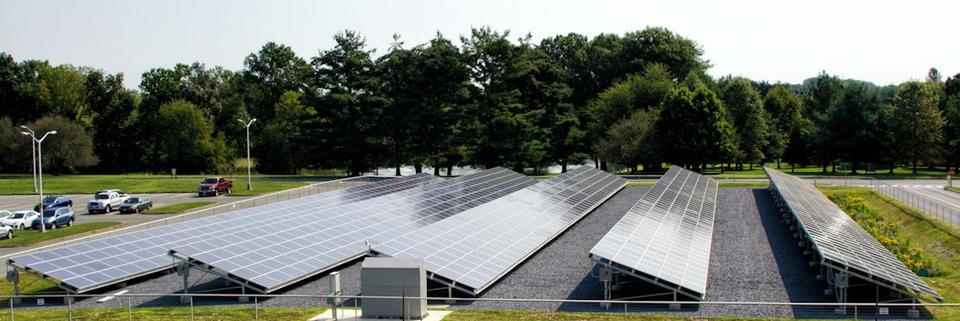
*Figure 1: NIST Ground Mount PV array used in this project.*

The raw files contain one-minute averaged measurements from the PV array and associated weather sensors. [4] This project uses the summer period of 2016: June, July and August.

The variables used in the analysis are:

| Raw column | Meaning | Used as |
|---|---|---|
| `TIMESTAMP` | measurement timestamp | time variable |
| `InvPDC_kW_Avg` | average inverter DC power | $P_{DC}$ |
| `SEWSPOAIrrad_Wm2_Avg` | plane-of-array irradiance | $G_{POA}$ |
| `SEWSModuleTemp_C_Avg` | PV module temperature | $T_m$ |

The key derived variables are:

| Derived column | Meaning |
|---|---|
| `expected_P_DC_kW` | irradiance-scaled expected DC power |
| `PR` | interval-based DC performance ratio |
| `logPR` | response variable for Bayesian modelling |
| `x_T` | min-max normalized module temperature |
| `T_range_C` | module temperature range used to convert the normalized temperature coefficient back to an effect per ($10^\circ C$) |
| `day_id` | consecutive day index used by the hierarchical daily-offset model |

### Modelling intuition

After defining $log(PR)$ as the response variable, the analysis focuses on two sources of variation in normalized PV performance.

The first source is module temperature:

```text
module temperature ───→ modelled log(PR)
```

Higher module temperature is expected to reduce PV performance, because increasing cell temperature mainly lowers the open-circuit voltage of the solar cells, which reduces the maximum power point.

The second source is day-to-day variation that remains after accounting for temperature:

```text
module temperature ───────────────┐
                                  ├──→ modelled log(PR)
day-specific deviation ───────────┘
```

These day-specific deviations are not treated as a direct measurement of one physical mechanism. Instead, they represent systematic daily underperformance or overperformance that may be related to residual weather effects, irradiance measurement mismatch, temporary shading, soiling-like losses, sensor issues, inverter behaviour, or other unmodelled operating conditions.


## 2. Data selection and preprocessing

In preprocessing step, we've focused on obtaining a reliable modelling dataset for pointwise performance ratio analysis. Preprocessing consists of few steps:

1. **Array and period selection**
   Only the NIST Ground Mount Array was used. The analysed period was June-August 2016.

2. **Performance-ratio calculation**
   The DC performance ratio was then calculated from the rated array power and plane-of-array irradiance as:

   $PR_i=\frac{P_{DC,i}}{P_{rated}\frac{G_{POA,i}}{G_{STC}}}.$

3. **Daytime filtering**  
   Only measurements between 09:00 and 16:00 were retained. This avoids low-irradiance periods near sunrise and sunset, where the denominator of the pointwise $PR$ calculation can be close to zero. In such cases, $PR$ can be strongly affected by power measurement noise and becomes poorly informative for modelling.

4. **Five-minute subsampling**
   The raw data are one-minute averages. To reduce dataset size and limit strong autocorrelation, only timestamps at five-minute intervals were retained.

5. **Temperature normalization**
   Module temperature was min-max normalized to the interval $[0,1]$:

   $x_{T,i}=\frac{T_{m,i}-T_{\min}}{T_{\max}-T_{\min}}.$

   The Stan models use this normalized predictor, while the temperature effect is reported as the performance change per $10^\circ C$.


In [2]:
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["logPR", "PR", "x_T", "T_range_C", "day_id"]).copy()
df = df.reset_index(drop=True)

_, df["day_id"] = np.unique(df["day_id"].to_numpy(), return_inverse=True)
df["day_id"] = df["day_id"] + 1

y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
day_id = df["day_id"].astype(int).to_numpy()

N = len(df)
J = int(df["day_id"].max())
T_range_C = float(df["T_range_C"].iloc[0])

print("Rows:", N)
print("Days:", J)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Module temperature range [degC]:", round(df["T_module_C"].min(), 2), "to", round(df["T_module_C"].max(), 2))
print("PR range:", round(df["PR"].min(), 4), "to", round(df["PR"].max(), 4))

example_cols = [
    "timestamp", "day_id", "P_DC_kW", "G_POA_Wm2", "T_module_C",
    "expected_P_DC_kW", "PR", "logPR", "x_T",
]

df[example_cols].head(5).round(4)

Rows: 4026
Days: 57
Date range: 2016-06-01 09:00:00 to 2016-08-31 16:00:00
Module temperature range [degC]: 14.78 to 66.68
PR range: 0.3633 to 2.5017


/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/ipykernel_13664/898648838.py:30: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df[example_cols].head(5).round(4)


,timestamp,day_id,P_DC_kW,G_POA_Wm2,T_module_C,expected_P_DC_kW,PR,logPR,x_T
0,2016-06-01 09:00:00,1,176.2,697.2,52.17,188.9412,0.9326,-0.0698,0.7204
1,2016-06-01 09:05:00,1,136.5,524.0,53.62,142.0040,0.9612,-0.0395,0.7484
2,2016-06-01 09:10:00,1,185.7,777.0,52.48,210.5670,0.8819,-0.1257,0.7264
3,2016-06-01 09:15:00,1,129.8,503.0,48.39,136.3130,0.9522,-0.0490,0.6476
4,2016-06-01 09:20:00,1,174.1,709.0,48.61,192.1390,0.9061,-0.0986,0.6518


## 4. Bayesian models

Two Bayesian models were specified. Both models use the same response variable:

$$
y_i = \log(PR_i),
$$

where $PR_i$ is the pointwise DC performance ratio. A Student-$t$ likelihood is used in both models:

$$
y_i \sim \mathrm{StudentT}(\nu, \mu_i, \sigma).
$$

The Student-$t$ distribution was chosen instead of Normal because PV monitoring data can contain occasional unusual observations caused by clouds, temporary shading, sensor noise or imperfect irradiance measurement. Heavier tails make the model less sensitive to individual outlying points.

### Model 1: temperature-only model

The first model describes normalized PV performance only as a function of module temperature:

$$
\mu_i = \alpha + \beta_{T,norm}x_{T,i}.
$$

Here, $\alpha$ is the baseline log-performance level, $x_{T,i}$ is the min-max normalized module temperature, and $\beta_{T,norm}$ is the temperature coefficient on the normalized scale.

To keep the result easily interpretable and comparable with literature [7], we use a parameter $\beta_{T,10C}$, which represents the effect on $\log(PR)$ for a $10^\circ C$ increase in module temperature. Inside the model it is converted to the normalized-temperature coefficient:

$$
\beta_{T,norm} = \beta_{T,10C}\frac{T_{range}}{10}.
$$

The main objective of this model is to estimate the average temperature-related performance loss and check whether the data support a negative temperature effect described in literature. [7]

### Model 2: temperature model with daily offsets

The second model keeps the same temperature effect, but adds a day-specific deviation:

$$
\mu_i = \alpha + \beta_{T,norm}x_{T,i} + \delta_{day[i]}.
$$

The daily offsets are modelled hierarchically:

$$
\delta_d \sim \mathrm{Normal}(0,\sigma_{day}).
$$

This model checks whether performance is stable from day to day after accounting for module temperature. The daily offset is not interpreted as one specific phenomena. It represents systematic daily under or overperformance that may be caused by  weather effects, irradiance mismatch, temporary shading, soiling-like losses, sensor issues or other unmodelled daily conditions.

The additional parameter $\sigma_{day}$ measures the typical scale of day-to-day variability in $\log(PR)$. Therefore, Model 2 is justified if temperature alone does not explain all systematic variation in the data.


## Priors
There are several parameters in the models that have priors. Both models use the same priors for the parameters that they have in common, and the second model has additional parameters with their own priors. The priors are as follows:
- `alpha`: expected value of $log(PR)$
- `beta`: expected change in $log(PR)$ per $\Delta T=1^{\circ}C$
- `sigma`: standard deviation of the Student-t distribution of $log(PR)$
- `nu`: degrees of freedom for the Student-t distribution of $log(PR)$

Only in the second model:
- `sigma_day`: scale parameter for day-level variation in Model 2. It controls how strongly individual days can deviate from the global temperature trend on the `log(PR)` scale. Larger values indicate stronger day-to-day variability not explained by temperature alone.
- `z_day_raw`: standardized latent daily effects. Each day receives a raw effect drawn from `Normal(0, 1)`. These raw effects are centered and multiplied by `sigma_day` to obtain the actual daily offsets:

  $$\delta_d = \sigma_{day}(z_{day,d} - \bar{z}_{day})$$


### Model 1: Prior predictive checks
The first model has the following priors:
- `alpha` ~ Normal(log(0.8), 0.3)

Justification: the average value of \(PR\) is usually around 88-93% [2]. We decided to use a slightly weaker prior mean of 75% to allow for some bias in the data and to give the model more room to learn from the data. The standard deviation of 0.3 allows for a wide range of plausible average performance values.

- `beta_T_10C` ~ Normal(-0.035, 0.05)

The prior mean of -0.035 corresponds to a 3.5% decrease in \(PR\) per 10°C increase in temperature, which is a reasonable starting point based on previous studies [3]. The standard deviation of 0.05 allows for a wide range of plausible effects, including no effect and stronger effects.

- `sigma` ~ Exponential(10)

This prior places more weight on smaller values but stills allows a wide range of values.

- `nu` ~ 5 + Exponential(0.1)

This prior allows for a wide range of degrees of freedom, starting from 5 (which corresponds to a moderately heavy-tailed distribution) and allowing for much heavier tails as well.

19:08:31 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
19:08:35 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
19:08:35 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 561.98it/s, (Sampling completed)]


19:08:40 - cmdstanpy - INFO - CmdStan done processing.


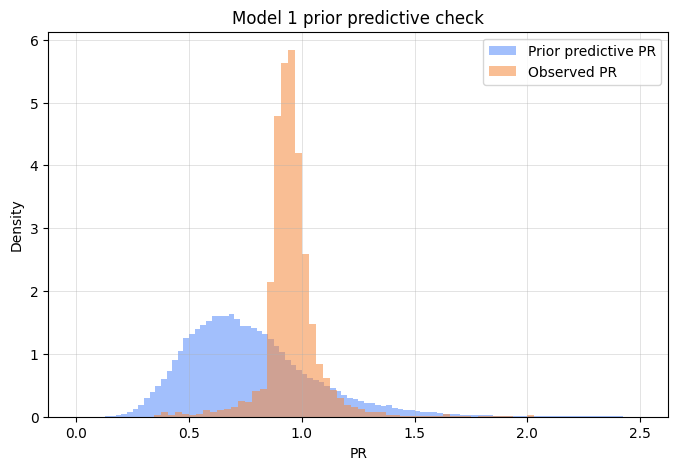

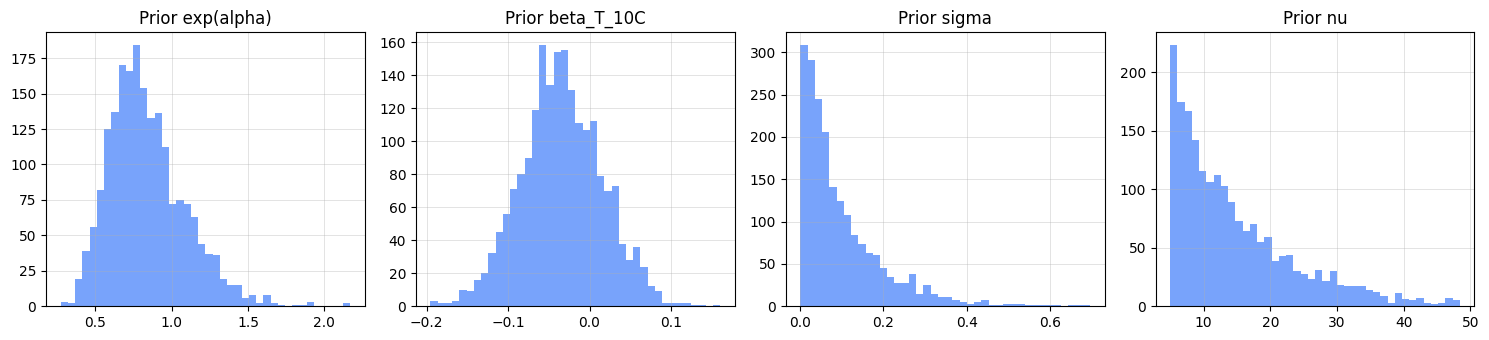

In [3]:
prior_data1 = {
    "N": N,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

prior_model1 = CmdStanModel(
    stan_file=str(STAN_PRIOR1_PATH),
    force_compile=True
)

prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    chains=1,
    iter_sampling=2000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit1.stan_variable("alpha")
beta_T_prior = prior_fit1.stan_variable("beta_T_10C")
sigma_prior = prior_fit1.stan_variable("sigma")
nu_prior = prior_fit1.stan_variable("nu")
PR_prior = prior_fit1.stan_variable("PR_prior")

plt.figure()
plt.hist(PR_prior.flatten(), bins=100, range=(0, 2.5), density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, range=(0, 2.5), density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Model 1 prior predictive check")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, samples) in zip(
    axes,
    [
        ("exp(alpha)", np.exp(alpha_prior)),
        ("beta_T_10C", beta_T_prior),
        ("sigma", sigma_prior),
        ("nu", nu_prior),
    ],
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

The prior predictive distribution is deliberately wider than the observed data. This means that the priors do not strongly constrain the model. In other words, the priors are weakly informative: they allow a broad range of possible outcomes.

As a result, the prior predictive check does not match the observed distribution closely, which is expected. A close match between the prior predictive distribution and the observed data could indicate that the priors are too specialized or too strongly informed by the data.

### Model 2: Prior predictive checks
The second model has the same priors for `alpha`, `beta_T_10C`, `sigma`, and `nu` as the first model, and it has additional priors for the day-level parameters:
- `sigma_day` ~ Normal(0, 1), half-normal on the positive side

This prior allows for a wide range of day-level variability, with most of the mass near zero but allowing for larger values as well.

- `z_day_raw` ~ Normal(0, 1)

This prior assumes that the raw day effects are centered around zero, allowing for both positive and negative deviations from the global trend.

19:08:43 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset_prior_predictive.stan to exe file /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset_prior_predictive
19:08:46 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset_prior_predictive
19:08:47 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 2000/2000 [00:02<00:00, 724.84it/s, (Sampling completed)]


19:08:50 - cmdstanpy - INFO - CmdStan done processing.


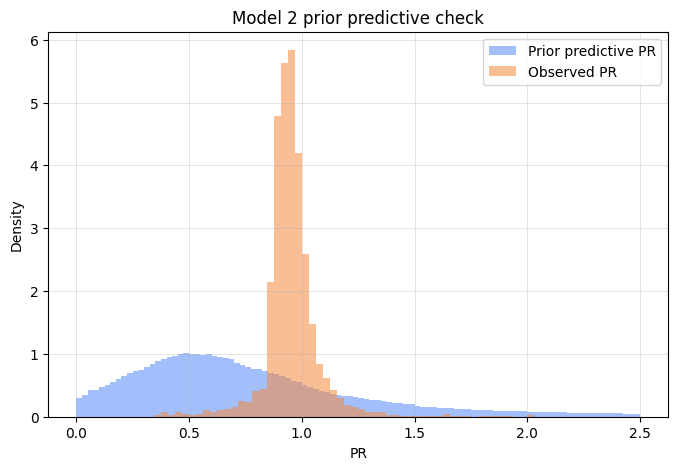

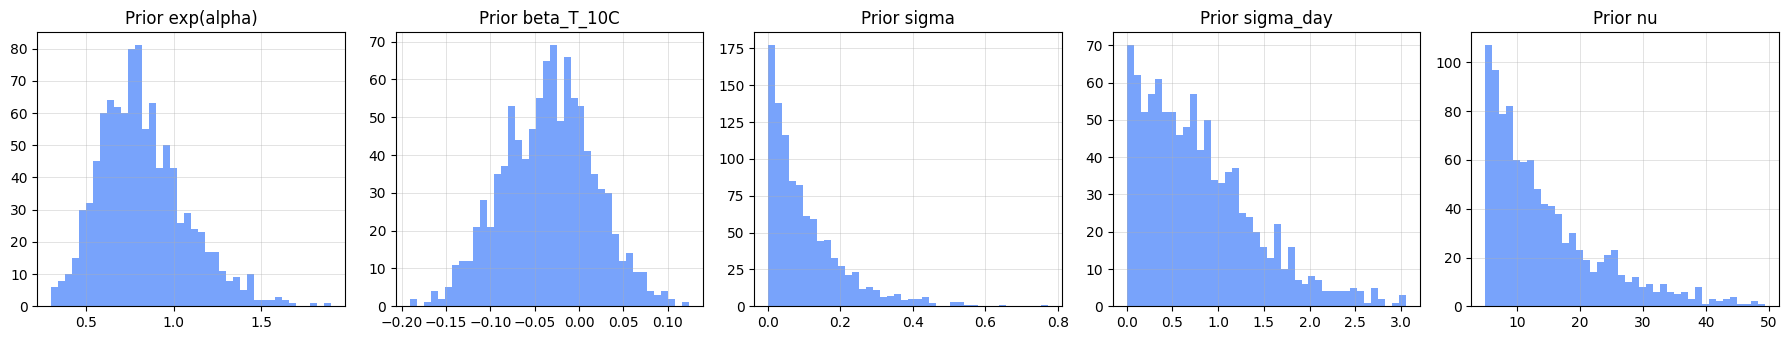

In [4]:
prior_data2 = {
    "N": N,
    "J": J,
    "x_T": x_T,
    "temp_range": T_range_C,
    "day_id": day_id,
}

prior_model2 = CmdStanModel(
    stan_file=str(STAN_PRIOR2_PATH),
    force_compile=True
)

prior_fit2 = prior_model2.sample(
    data=prior_data2,
    fixed_param=True,
    chains=1,
    iter_sampling=1000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit2.stan_variable("alpha")
beta_T_prior = prior_fit2.stan_variable("beta_T_per_10C")
sigma_prior = prior_fit2.stan_variable("sigma")
sigma_day_prior = prior_fit2.stan_variable("sigma_day")
nu_prior = prior_fit2.stan_variable("nu")
PR_prior = prior_fit2.stan_variable("PR_prior")

plt.figure(figsize=(8, 5))
plt.hist(PR_prior.flatten(), range=(0, 2.5), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, range=(0, 2.5), density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Model 2 prior predictive check")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
prior_samples = [
    ("exp(alpha)", np.exp(alpha_prior)),
    ("beta_T_10C", beta_T_prior),
    ("sigma", sigma_prior),
    ("sigma_day", sigma_day_prior),
    ("nu", nu_prior),
]

for ax, (name, samples) in zip(axes, prior_samples):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)

plt.tight_layout()
plt.show()

Prior predictive checks for Model 2 show that the prior predictive distribution is wider than the observed data, similar to Model 1. This indicates that the priors are weakly informative and allow for a broad range of possible outcomes. The additional day-level parameters introduce more variability, which is reflected in the prior predictive distribution.

## Model 1 - Posterior analysis

### Fit Model 1

Model 1 estimates the average temperature effect on normalized PV performance using a Student-t likelihood.

In [5]:
stan_data1 = {
    "N": len(df),
    "y": df["logPR"].to_numpy(),
    "x_T": df["x_T"].to_numpy(),
    "T_range_C": float(df["T_range_C"].iloc[0]),
}

model1 = CmdStanModel(stan_file=str(STAN_MODEL1_PATH), force_compile=True)
fit1 = model1.sample(
    data=stan_data1,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

fit1

19:08:51 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt
19:08:55 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt
19:08:55 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 2:   5%|▌         | 100/2000 [00:00<00:03, 614.62it/s, (Warmup)]


chain 4:   5%|▌         | 100/2000 [00:00<00:04, 388.38it/s, (Warmup)]

chain 2:  10%|█         | 200/2000 [00:00<00:04, 391.84it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:01<00:07, 229.75it/s, (Warmup)]


chain 2:  20%|██        | 400/2000 [00:01<00:06, 254.83it/s, (Warmup)]


chain 2:  25%|██▌       | 500/2000 [00:01<00:06, 247.57it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:02<


19:09:07 - cmdstanpy - INFO - CmdStan done processing.


CmdStanMCMC: model=model_1_temperature_studentt chains=4['method=sample', 'num_samples=1000', 'num_warmup=1000', 'algorithm=hmc', 'engine=nuts', 'max_depth=12', 'adapt', 'engaged=1', 'delta=0.95']
 csv_files:
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_1_temperature_studenttwa8ghbgx/model_1_temperature_studentt-20260621190855_1.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_1_temperature_studenttwa8ghbgx/model_1_temperature_studentt-20260621190855_2.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_1_temperature_studenttwa8ghbgx/model_1_temperature_studentt-20260621190855_3.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_1_temperature_studenttwa8ghbgx/model_1_temperature_studentt-20260621190855_4.csv
 output_files:
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_1_temperature_studenttwa8ghbgx/model_1_temperature_studentt-20260621190855_0-stdout.txt
	/var/folders/3t/tbwyt4z

### Diagnostics

In [6]:
print(fit1.diagnose())
summary1 = fit1.summary()
important_params1 = [p for p in ["alpha", "beta_T_10C", "beta_T_norm", "beta_T", "sigma", "nu"] if p in summary1.index]
display(summary1.loc[important_params1])

draws_pd = fit1.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,0.126775,0.000073,0.003732,0.003691,0.120609,0.126763,0.132911,2605.68,1868.13,93.1866,1.00023
beta_T_10C,-0.057509,0.000022,0.001141,0.001132,-0.059352,-0.057510,-0.055612,2628.81,2106.41,94.0135,1.00004
beta_T_norm,-0.298470,0.000116,0.005922,0.005874,-0.308038,-0.298479,-0.288625,2628.80,2106.41,94.0135,1.00005
sigma,0.054840,0.000019,0.000894,0.000875,0.053355,0.054844,0.056289,2290.91,2199.82,81.9293,1.00078
nu,5.007700,0.000171,0.007990,0.005428,5.000400,5.005160,5.022670,1504.76,1027.92,53.8145,1.00114


Number of divergences: 0


#### Sampling diagnostics summary
The sampler diagnostics did not indicate sampling problems for Model 1: no divergent transitions were found, E-BFMI was satisfactory, and the reported R-hat values were close to 1. Because the diagnostics were satisfactory, no additional mitigation was needed.

### Posterior predictive check

The posterior predictive distribution was compared with the observed $PR$ distribution. This checks whether the fitted model can reproduce the main structure of the measured normalized PV performance.

nu [5%, 50%, 95%]: [5.00039885 5.0051648  5.0226748 ]


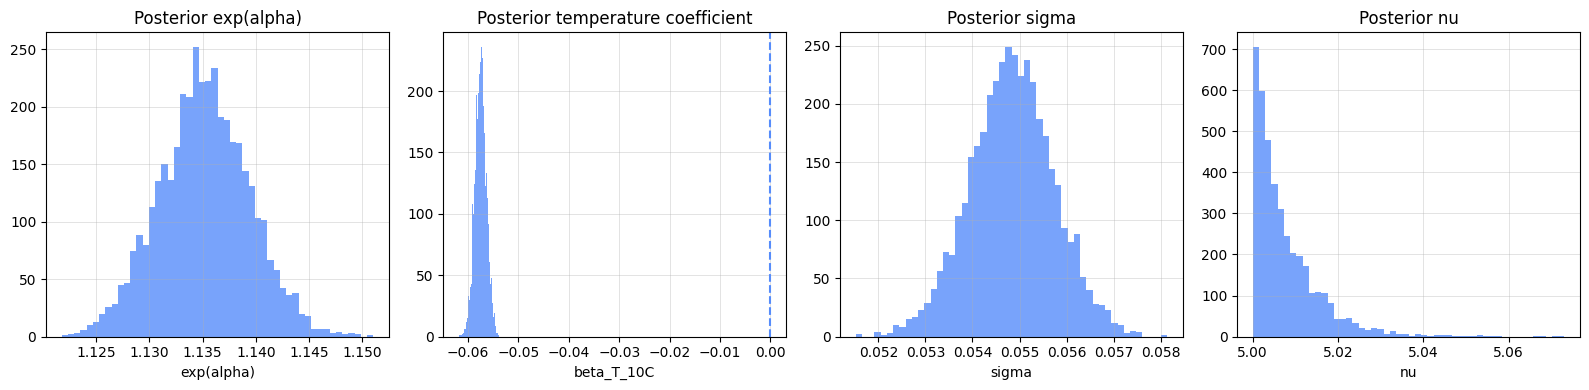

In [7]:
alpha = fit1.stan_variable("alpha")
beta_T_10C = fit1.stan_variable("beta_T_10C")
beta_T_norm = fit1.stan_variable("beta_T_norm")
sigma = fit1.stan_variable("sigma")
nu = fit1.stan_variable("nu")
mu = fit1.stan_variable("mu")

print("nu [5%, 50%, 95%]:", np.percentile(nu, [5, 50, 95]))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior exp(alpha)", np.exp(alpha), "exp(alpha)", False),
    ("Posterior temperature coefficient", beta_T_10C, "beta_T_10C", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]

for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)

plt.tight_layout()
plt.show()

The posterior $exp(alpha)$ represents the expected PR at the lowest observed temperature. Its values are concentrated above 1, which is expected because the estimated temperature effect is negative, so PR decreases as temperature increases. The posterior for beta_T_10C is concentrated below zero, indicating a stable negative temperature effect, while sigma and nu summarize the residual spread and tail heaviness of the Student-t likelihood.

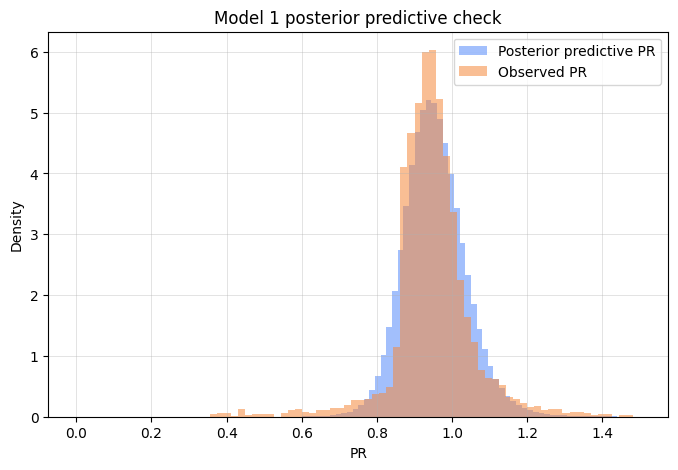

In [8]:
PR_pred = fit1.stan_variable("PR_pred")
y_pred = fit1.stan_variable("y_pred")

plt.figure(figsize=(8, 5))
plt.hist(PR_pred.flatten(), bins=100, range=(0, 1.5), density=True, alpha=0.55, label="Posterior predictive PR")
plt.hist(df["PR"], bins=80, range=(0, 1.5), density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Model 1 posterior predictive check")
plt.legend()
plt.grid(True)
plt.show()

The posterior predictive distribution of PR is more concentrated around the observed data compared to the prior predictive distribution, which indicates that the model has learned from the data. The posterior predictive samples are analyzed by comparing their distribution with the empirical PR distribution.

The observed data are broadly consistent with the posterior predictive samples: the main mass of the observed PR distribution is covered by the posterior predictive distribution. Remaining differences are expected because Model 1 is simple and only includes temperature.

### Residual diagnostics: motivation for Model 2

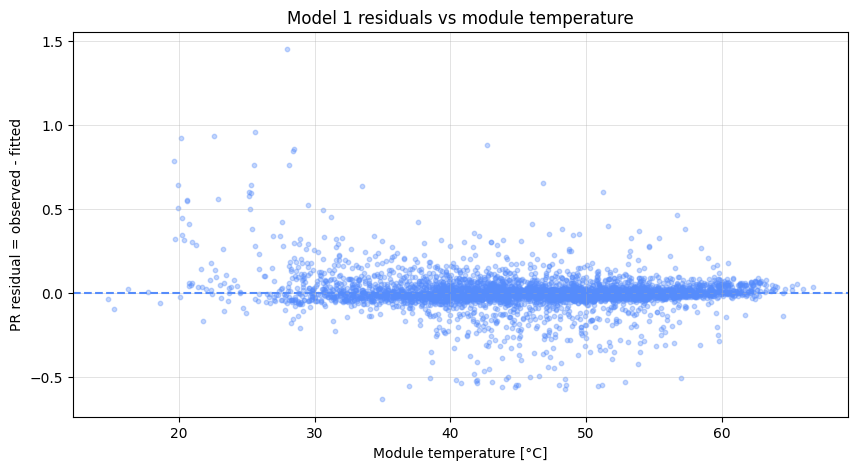

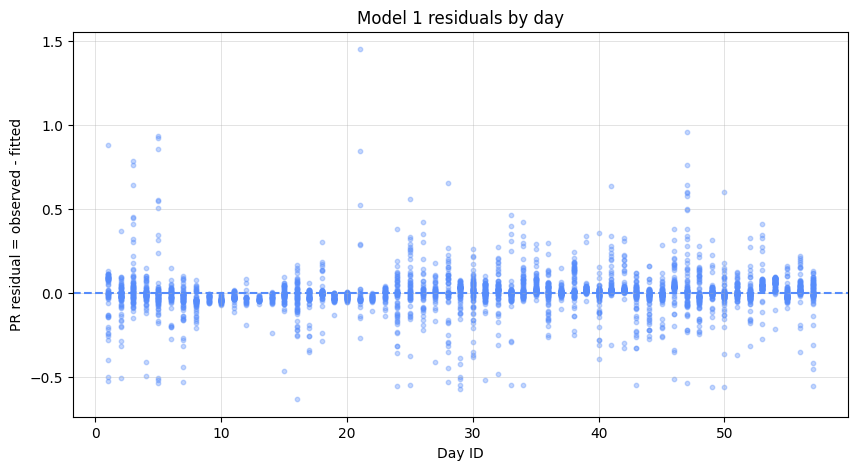

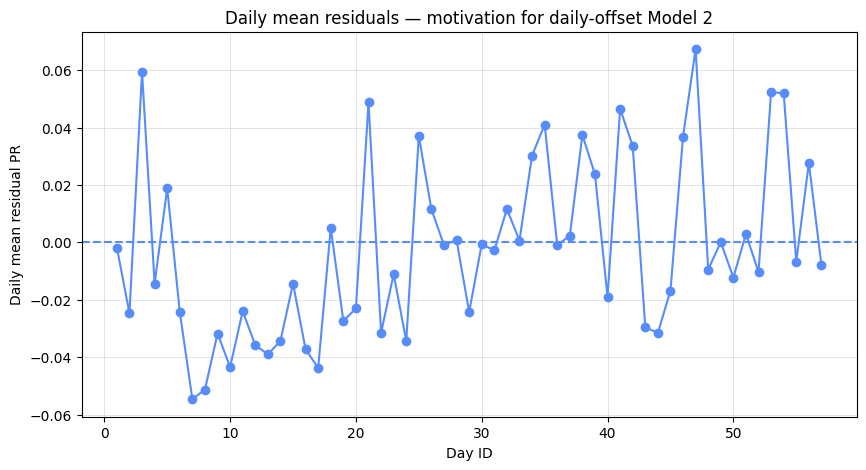

In [9]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check1 = df.copy()
df_check1["PR_pred_mean"] = PR_mu_mean
df_check1["residual_PR"] = df_check1["PR"] - df_check1["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check1["T_module_C"], df_check1["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - fitted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df_check1["day_id"], df_check1["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("PR residual = observed - fitted")
plt.title("Model 1 residuals by day")
plt.show()

daily_res1 = df_check1.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
plt.figure(figsize=(10, 5))
plt.plot(daily_res1["day_id"], daily_res1["daily_mean_residual"], "o-")
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("Daily mean residual PR")
plt.title("Daily mean residuals — motivation for daily-offset Model 2")
plt.show()

In [10]:
idata1 = az.from_cmdstanpy(
    posterior=fit1,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

Residuals from Model 1 were inspected to check whether the temperature-only model leaves systematic structure in the data. Visible day-to-day residual patterns motivate the use of daily offsets in Model 2.

## Model 2 - Posterior analysis

### Fit Model 2

Model 2 keeps the temperature effect from Model 1 and adds a latent daily offset. The additional term allows the model to represent systematic daily overperformance or underperformance that remains after accounting for module temperature.

In [11]:
stan_data_2 = {
    "N": len(df),
    "J": int(df["day_id"].nunique()),
    "y": df["logPR"].to_numpy(),
    "x_T": df["x_T"].to_numpy(),
    "temp_range": float(df["T_range_C"].iloc[0]),
    "day_id": df["day_id"].astype(int).to_numpy(),
}

model2 = CmdStanModel(stan_file=str(STAN_MODEL2_PATH), force_compile=True)
fit2 = model2.sample(
    data=stan_data_2,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

fit2

19:10:23 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset.stan to exe file /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset
19:10:29 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_2_temperature_daily_offset
19:10:29 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   5%|▌         | 100/2000 [00:14<04:44,  6.68it/s, (Warmup)]

chain 3:  10%|█         | 200/2000 [00:17<02:21, 12.76it/s, (Warmup)]

chain 3:  15%|█▌        | 300/2000 [00:20<01:29, 19.03it/s, (Warmup)]

chain 3:  20%|██        | 400/2000 [00:21<00:59, 26.85it/s, (Warmup)]

chain 3:  25%|██▌       | 500/2000 [00:22<00:44, 33.82it/s, (Warmup)]

chain 3:  30%|███       | 600/2000 [00:24<00:32, 42


19:11:33 - cmdstanpy - INFO - CmdStan done processing.


CmdStanMCMC: model=model_2_temperature_daily_offset chains=4['method=sample', 'num_samples=1000', 'num_warmup=1000', 'algorithm=hmc', 'engine=nuts', 'max_depth=12', 'adapt', 'engaged=1', 'delta=0.95']
 csv_files:
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_2_temperature_daily_offsettmvt9gbb/model_2_temperature_daily_offset-20260621191029_1.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_2_temperature_daily_offsettmvt9gbb/model_2_temperature_daily_offset-20260621191029_2.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_2_temperature_daily_offsettmvt9gbb/model_2_temperature_daily_offset-20260621191029_3.csv
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_2_temperature_daily_offsettmvt9gbb/model_2_temperature_daily_offset-20260621191029_4.csv
 output_files:
	/var/folders/3t/tbwyt4z518nbvz3s3vw6y8h80000gn/T/tmpazmbsggm/model_2_temperature_daily_offsettmvt9gbb/model_2_temperature_daily_offset-20260621

### Diagnostics

The diagnostics are used to check whether the posterior samples can be trusted. The main checks are divergent transitions, $\hat{R}$ values close to 1, and reasonable effective sample sizes.

In [12]:
print(fit2.diagnose())
summary2 = fit2.summary()
important_params2 = [p for p in ["alpha", "beta_T", "beta_T_norm", "beta_T_per_10C", "beta_T_10C", "sigma", "sigma_day", "nu", "nu_minus_two"] if p in summary2.index]
display(summary2.loc[important_params2])

draws_pd = fit2.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  z_day_raw[56]
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.

Processing complete.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,0.182218,0.000086,0.004458,0.004445,0.174890,0.182250,0.189566,2687.73,3071.650,56.89530,1.000760
beta_T,-0.393993,0.000141,0.007259,0.007231,-0.405767,-0.393970,-0.381974,2670.65,2940.260,56.53360,1.000630
beta_T_per_10C,-0.075914,0.000027,0.001399,0.001393,-0.078183,-0.075909,-0.073598,2670.65,2940.260,56.53360,1.000630
sigma,0.046081,0.000013,0.000788,0.000774,0.044785,0.046078,0.047363,3819.14,3079.670,80.84550,0.999551
sigma_day,0.032500,0.000170,0.003436,0.003316,0.027310,0.032218,0.038598,418.37,680.936,8.85627,1.007850
nu,5.005890,0.000078,0.005880,0.004217,5.000310,5.004170,5.017690,2710.04,1085.140,57.36760,1.000020


Number of divergences: 0


### Temperature effect summary

The same temperature-effect summary is computed for Model 2. This checks whether the negative temperature effect remains after accounting for day-specific deviations.

In [13]:
beta_T_10C = fit2.stan_variable("beta_T_per_10C")
effect_10C_pct_model2 = 100 * (np.exp(beta_T_10C) - 1)
effect_1C_pct_model2 = 100 * (np.exp(beta_T_10C / 10.0) - 1)

print("P(beta_T_10C < 0):", round(np.mean(beta_T_10C < 0), 4))
print("beta_T_10C [5%, 50%, 95%]:", np.round(np.percentile(beta_T_10C, [5, 50, 95]), 4))
print("Effect per +10°C [%] [5%, 50%, 95%]:", np.round(np.percentile(effect_10C_pct_model2, [5, 50, 95]), 3))
print("Effect per +1°C [%] [5%, 50%, 95%]:", np.round(np.percentile(effect_1C_pct_model2, [5, 50, 95]), 3))

P(beta_T_10C < 0): 1.0
beta_T_10C [5%, 50%, 95%]: [-0.0782 -0.0759 -0.0736]
Effect per +10°C [%] [5%, 50%, 95%]: [-7.52  -7.31  -7.095]
Effect per +1°C [%] [5%, 50%, 95%]: [-0.779 -0.756 -0.733]


#### Sampling diagnostics summary

The sampler diagnostics did not indicate serious sampling problems for Model 2. No divergent transitions were found, and the inspected convergence diagnostics were acceptable. The model was sampled with `adapt_delta = 0.95` and `max_treedepth = 12`, which was sufficient for the final fit.

### Marginal posterior distributions

The main physical parameter is the temperature effect per $10^\circ C$. The daily variability is summarized by $\sigma_{day}$, which measures the typical scale of day-to-day deviations in $\log(PR)$ after accounting for temperature.

nu [5%, 50%, 95%]: [5.00031203 5.0041651  5.01769474]
sigma_day [5%, 50%, 95%]: [0.02731014 0.03221781 0.0385979 ]


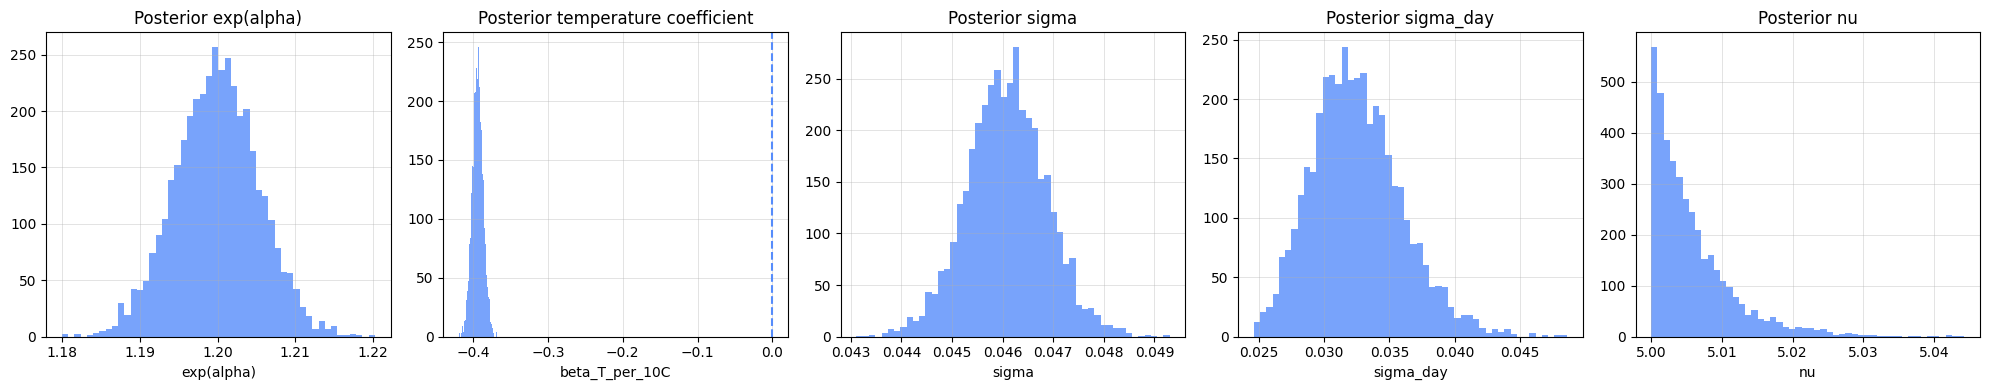

In [14]:
alpha = fit2.stan_variable("alpha")
beta_T_per_10C = fit2.stan_variable("beta_T_per_10C")
beta_T = fit2.stan_variable("beta_T")
sigma = fit2.stan_variable("sigma")
sigma_day = fit2.stan_variable("sigma_day")
nu = fit2.stan_variable("nu")
mu = fit2.stan_variable("mu")
delta_day = fit2.stan_variable("delta_day")

print("nu [5%, 50%, 95%]:", np.percentile(nu, [5, 50, 95]))
print("sigma_day [5%, 50%, 95%]:", np.percentile(sigma_day, [5, 50, 95]))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
plots = [
    ("Posterior exp(alpha)", np.exp(alpha), "exp(alpha)", False),
    ("Posterior temperature coefficient", beta_T, "beta_T_per_10C", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior sigma_day", sigma_day, "sigma_day", False),
    ("Posterior nu", nu, "nu", False),
]

for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)

plt.tight_layout()
plt.show()

### Posterior predictive check

The posterior predictive distribution is compared with the observed $PR$ distribution. This check verifies whether the fitted model can generate data similar to the observed data.

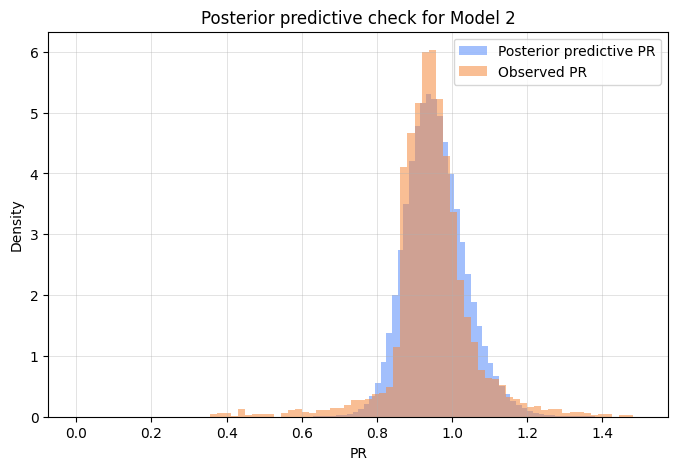

In [15]:
PR_pred = fit2.stan_variable("PR_pred")
y_pred = fit2.stan_variable("y_pred")

plt.figure(figsize=(8, 5))
plt.hist(PR_pred.flatten(), bins=100, range=(0, 1.5), density=True, alpha=0.55, label="Posterior predictive PR")
plt.hist(df["PR"], bins=80, range=(0, 1.5), density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check for Model 2")
plt.legend()
plt.grid(True)
plt.show()

The posterior predictive distribution of Model 2 closely overlaps with the observed $PR$ distribution, especially around the main peak. This indicates that the model with daily offsets reproduces the main structure of the observed normalized PV performance reasonably well, although some extreme low and high $PR$ values remain less well captured.

In [16]:
idata2 = az.from_cmdstanpy(
    posterior=fit2,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model2_temperature_daily_offset.pkl", "wb") as f:
    pickle.dump(idata2, f)

## Model comparison

WAIC and PSIS-LOO estimate out-of-sample predictive accuracy using the pointwise log-likelihood. In both criteria, a larger expected log predictive density (`elpd`) is better. The `rank` column orders the models, while `elpd_diff` shows the difference from the best model.

## WAIC

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,4793.019592,42.939701,0.000000,0.999887,126.570241,0.000000,False,log
Model 1: temperature Student-t,1,4344.974644,3.920090,448.044948,0.000113,113.418848,27.451602,False,log


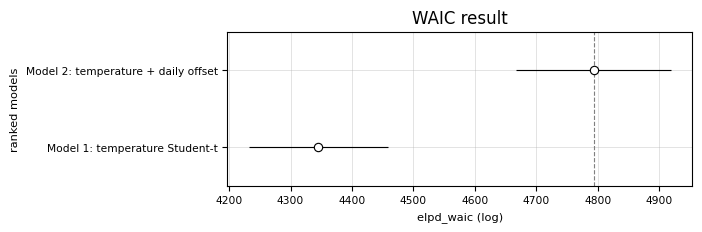

In [17]:
idatas = {
    "Model 1: temperature Student-t": idata1,
    "Model 2: temperature + daily offset": idata2,
}

comp_waic = az.compare(idatas, ic="waic", scale="log")
display(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC result")
plt.show()

## PSIS-LOO

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,4792.951979,43.007314,0.000000,0.999841,126.570618,0.000000,False,log
Model 1: temperature Student-t,1,4344.969992,3.924741,447.981986,0.000159,113.418950,27.451886,False,log


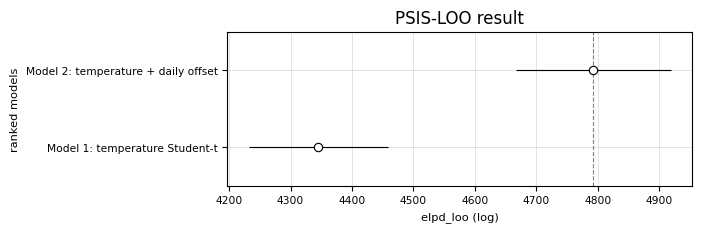

In [18]:
comp_loo = az.compare(idatas, ic="loo", scale="log")
display(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO result")
plt.show()

## Residual comparison

,mean_residual_pp,sd_residual_pp,MAE_pp,RMSE_pp
model,,,,
Model 1: temperature Student-t,-0.169267,11.103509,5.815195,11.103420
Model 2: temperature + daily offset,-0.370791,10.601359,5.120797,10.606525


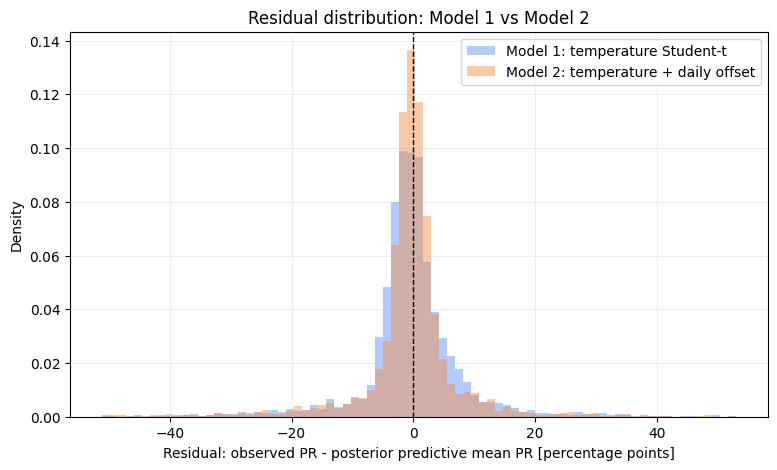

In [19]:
model_names = list(idatas)
y_obs = idatas[model_names[0]].observed_data["y"].values
PR_obs = np.exp(y_obs)
residuals = {}
residual_summary = []

for model_name, idata in idatas.items():

    y_pred = idata.posterior_predictive["y_pred"].values
    PR_pred_mean = np.exp(y_pred).mean(axis=(0, 1))
    residual = PR_obs - PR_pred_mean
    residuals[model_name] = residual

    residual_summary.append(
        {
            "model": model_name,
            "mean_residual_pp": 100 * np.mean(residual),
            "sd_residual_pp": 100 * np.std(residual, ddof=1),
            "MAE_pp": 100 * np.mean(np.abs(residual)),
            "RMSE_pp": 100 * np.sqrt(np.mean(residual**2)),
        }
    )

residual_summary = pd.DataFrame(residual_summary).set_index("model")
display(residual_summary)

all_residuals_pp = np.concatenate([100 * r for r in residuals.values()])
q_low, q_high = np.percentile(all_residuals_pp, [0.5, 99.5])
bins = np.linspace(q_low, q_high, 80)

plt.figure(figsize=(9, 5))
for model_name, residual in residuals.items():
    plt.hist(
        100 * residual,
        bins=bins,
        density=True,
        alpha=0.45,
        label=model_name,
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Residual: observed PR - posterior predictive mean PR [percentage points]")
plt.ylabel("Density")
plt.title("Residual distribution: Model 1 vs Model 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final assessment

Both information criteria and residual distribution agree that Model 2 has better predictive performance than Model 1. We agree with this selection because Model 2 includes day-level variation, which captures systematic differences between days that cannot be explained by temperature alone. Although Model 2 is more complex, the improvement in predictive accuracy is large and there are no WAIC or PSIS-LOO warnings, so the additional complexity is justified.

## References

[1] PV Performance Modeling Collaborative, Sandia National Laboratories. *Performance Ratio*.  
https://pvpmc.sandia.gov/modeling-guide/5-ac-system-output/pv-performance-metrics/performance-ratio/

[2] National Institute of Standards and Technology. *Photovoltaic Testbeds*.  
https://www.nist.gov/el/beed/heat-transfer-alternative-energy-systems/photovoltaic-testbeds

[3] National Institute of Standards and Technology. *Ground Mount Array*.  
https://www.nist.gov/el/beed/heat-transfer-alternative-energy-systems/photovoltaic-testbeds/ground-mount-array

[4] Boyd, M. T. (2017). *High-Speed Monitoring of Multiple Grid-Connected Photovoltaic Array Configurations and Weather Station Data*. NIST Technical Note 1896.  
https://nvlpubs.nist.gov/nistpubs/TechnicalNotes/NIST.TN.1896.pdf

[5] U.S. Department of Energy / NREL. *Understanding Solar Photovoltaic System Performance*.  
https://www.energy.gov/sites/default/files/2022-02/understanding-solar-photo-voltaic-system-performance.pdf

[6] PV Education. Effect of Temperature.  
https://www.pveducation.org/pvcdrom/solar-cell-operation/effect-of-temperature

[7] A. P. Dobos, *PVWatts Version 5 Manual*, National Renewable Energy Laboratory, Technical Report NREL/TP-6A20-62641, 2014. Available: https://pvwatts.nrel.gov/downloads/pvwattsv5.pdf